## Описание задания:

Вы справились с исследованием данных. Ваша стажировка продолжается, но в мире произошли непредвиденные события — пандемия COVID-19. Вдобавок заканчивается подотчётный период, и вам доверена срочная задача. Чтобы сформировать понимание о дальнейшей стратегии компании, необходимо определить возможные последствия.

1. Используйте датасет data_hw_reg.xlsx
2. Рассчитайте коэффициент корреляции между заболеваемостью и смертностью.
3. Постройте уравнение линейной регрессии по смертям от заболеваемости и вычислите прогноз количества смертей в России для 25 000 000 случаев заражений.

### Чек-лист проверки задания:

1. Рассчитан коэффициент корреляции заболеваемости и смертности.
2. Визуализирована динамика заболеваемости и смертности по странам.
3. Построено уравнение линейной регрессии с зависимостью смертности от заболеваемости и получен прогноз.
4. Сделаны выводы по полученным данным: коэффициенту корреляции, графикам динамики, параметрам уравнения регрессии и прогнозу.

In [82]:
import pandas as pd
import statistics as st
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [67]:
df = pd.read_excel("data_hw_reg.xlsx")
df.head()

,date,country,confirmed,deaths
0,2020-01-22,Russia,0,0
1,2020-01-22,US,1,0
2,2020-01-23,Russia,0,0
3,2020-01-23,US,1,0
4,2020-01-24,Russia,0,0


In [68]:
df.describe()

,date,confirmed,deaths
count,1116,1.116000e+03,1116.000000
mean,2020-10-26 12:00:00,8.508892e+06,169543.963262
min,2020-01-22 00:00:00,0.000000e+00,0.000000
25%,2020-06-09 00:00:00,8.245898e+05,15199.000000
50%,2020-10-26 12:00:00,3.840895e+06,98314.000000
75%,2021-03-15 00:00:00,8.748694e+06,226763.000000
max,2021-08-01 00:00:00,3.500342e+07,613228.000000
std,NaN,1.130533e+07,198133.420131


In [69]:
df['country_rus'] = df['country'].apply(lambda x: 1 if x == 'Russia' else 0)

In [70]:
# Корреляция заболеваемость к смертности
df['confirmed'].corr(df['deaths'])

np.float64(0.9898359549904742)

In [71]:
# Матрица корреляции
df[['country_rus','confirmed', 'deaths']].corr().style.background_gradient(cmap='coolwarm')

,country_rus,confirmed,deaths
country_rus,1.000000,-0.549407,-0.611675
confirmed,-0.549407,1.000000,0.989836
deaths,-0.611675,0.989836,1.000000


## Построение Линейной регрессии для России

In [72]:
df_ru = df[df['country'] == 'Russia'].copy()
X = df_ru[['confirmed']]
y = df_ru[['deaths']]

In [73]:
from sklearn.linear_model import LinearRegression # Подключение модуля Линейной регрессии
regressor = LinearRegression()                    # Инициализация Линейной регрессии
regressor.fit(X, y)                               # Обучение Линейной регрессии

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.02]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['confirmed']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-5713.83]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [74]:
# Коэффициент прямой
a = regressor.intercept_
a

array([-5713.82792078])

In [75]:
# Коэффициент наклона прямой
b = regressor.coef_
b

array([[0.02352537]])

In [76]:
# Прогназируем число смертей
infected  = 25000000
regressor.predict([[infected ]])

c:\Users\wolftik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[582420.3846451]])

In [77]:
# Качество модели
regressor.score(X, y)

0.9799213910252874

c:\Users\wolftik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


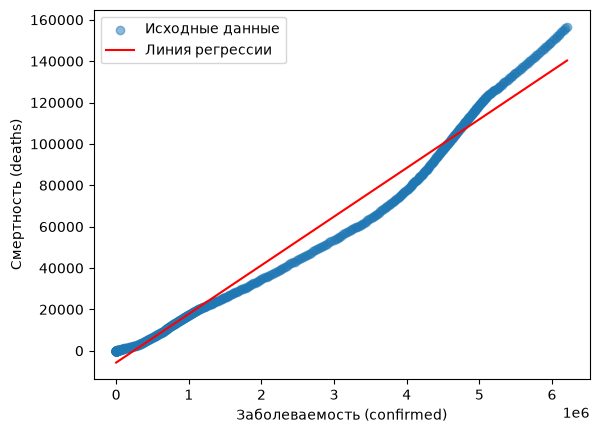

In [78]:
# Берём диапазон от min до max по оси X (заболеваемости) 
x_line = np.linspace(X.min(), X.max(), 100)
# Предсказываем y (смертности) для этих точек
y_line = regressor.predict(x_line.reshape(-1, 1))

# 2. Строим scatter исходных точек и накладываем линию
plt.scatter(X, y, alpha=0.5, label='Исходные данные')
plt.plot(x_line, y_line, color='red', label='Линия регрессии')
plt.xlabel('Заболеваемость (confirmed)')
plt.ylabel('Смертность (deaths)')
plt.legend()

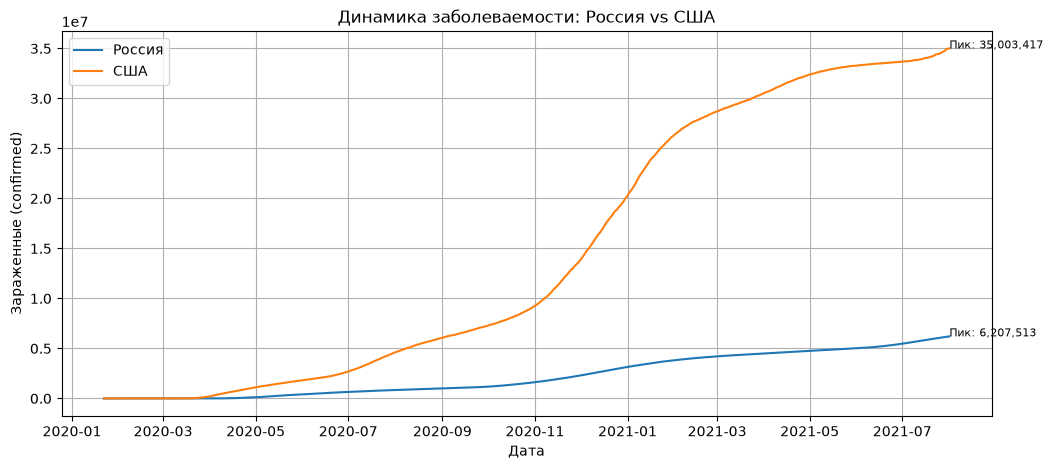

In [93]:
# Динамика заболеваемости по странам

df_ru = df_ru.sort_values('date')
df_us = df[df['country']=='US'].copy().sort_values('date')

plt.figure(figsize=(12, 5))

plt.plot(df_ru['date'], df_ru['confirmed'], label='Россия')
plt.plot(df_us['date'], df_us['confirmed'], label='США')

ru_idx_max = df_ru['confirmed'].idxmax()
plt.text(df_ru.loc[ru_idx_max, 'date'], df_ru.loc[ru_idx_max, 'confirmed'],
         f"Пик: {df_ru['confirmed'].max():,.0f}", fontsize=8)

us_idx_max = df_us['confirmed'].idxmax()
plt.text(df_us.loc[us_idx_max, 'date'], df_us.loc[us_idx_max, 'confirmed'],
         f"Пик: {df_us['confirmed'].max():,.0f}", fontsize=8)

plt.xlabel('Дата')
plt.ylabel('Зараженные (confirmed)')
plt.title('Динамика заболеваемости: Россия vs США')
plt.legend()
plt.grid(True)
plt.show()

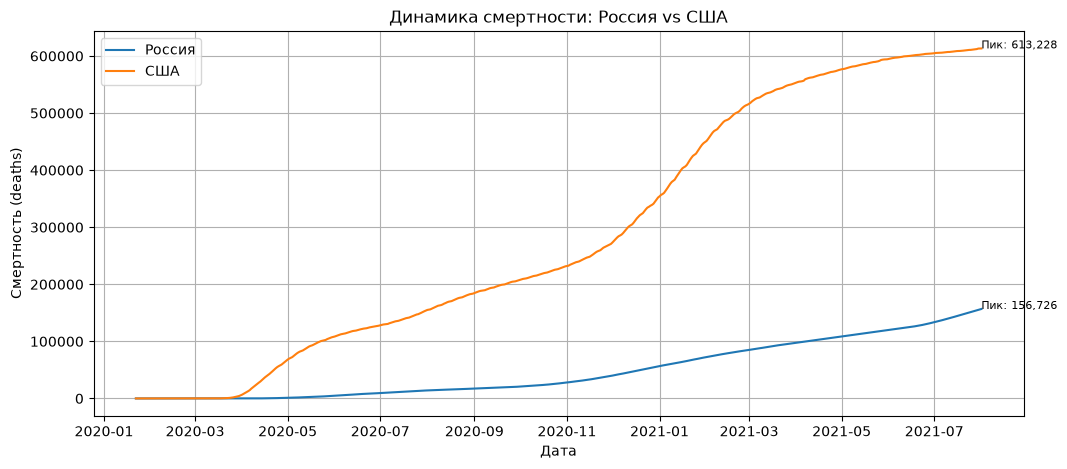

In [94]:
plt.figure(figsize=(12, 5))

plt.plot(df_ru['date'], df_ru['deaths'], label='Россия')
plt.plot(df_us['date'], df_us['deaths'], label='США')

ru_idx_max = df_ru['deaths'].idxmax()
plt.text(df_ru.loc[ru_idx_max, 'date'], df_ru.loc[ru_idx_max, 'deaths'],
         f"Пик: {df_ru['deaths'].max():,.0f}", fontsize=8)

us_idx_max = df_us['deaths'].idxmax()
plt.text(df_us.loc[us_idx_max, 'date'], df_us.loc[us_idx_max, 'deaths'],
         f"Пик: {df_us['deaths'].max():,.0f}", fontsize=8)

plt.xlabel('Дата')
plt.ylabel('Смертность (deaths)')
plt.title('Динамика смертности: Россия vs США')
plt.legend()
plt.grid(True)
plt.show()

## Выводы

### 1. Корреляционный анализ
- Корреляция положительная сильная ~0.99 говорит о прямой зависимости заболеваний и смертности.

### 2. Динамика заболеваемости и смертности
- По графику заболеваемости видно что тренд в целом восходящий. 
- С ноября 2020 резко ускорилась заболеваемость в США вплоть до марта 2021. Затем темп снизился. 
- В России тенденция более линейная без особых всплесков.
- По графику смертности тенденция аналогично заболеванию, о чем нам и говорит также корреляция.
- Разница между странами в 5-6 раз по уровню зараженных и смертности.

### 3. Уравнение регрессии
- Коэффициент наклона прямой (b) по России составляет ~ 0.0235 говорит нам о том что на 1000 заболевших приходится ~24 дополнительные смерти.
- Коэффициент наклона прямой (a) по России отрицательный ~ -5713, говорит о том что при нулевом заражении будут отрицательные смерти

Т.е. на начальном этапе модель неидеальна, но в больших маштабах заражении дает более адекватные прогнозы. О чем говорит качество модели ~0.98 означает что модель объясняет 98% вариаций смертности.

### 4. Прогноз
Согласно прогнозу модели на 25млн. зараженных получим ~582420 смертей. Однако модель линейная, она не расскрывает реальную картику эпидемии, не учитывает выход на плато с учетом возрастающего общего имунитета общества и вацинации.

